In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv(r"C:\Users\Sahil more\Downloads\heart disease.csv")
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (303, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


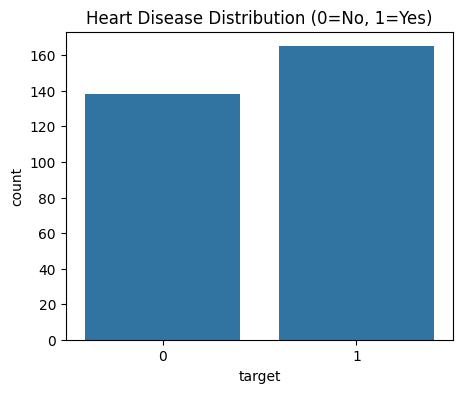

In [4]:
plt.figure(figsize=(5, 4))
sns.countplot(x="target", data=df)
plt.title("Heart Disease Distribution (0=No, 1=Yes)")
plt.show()

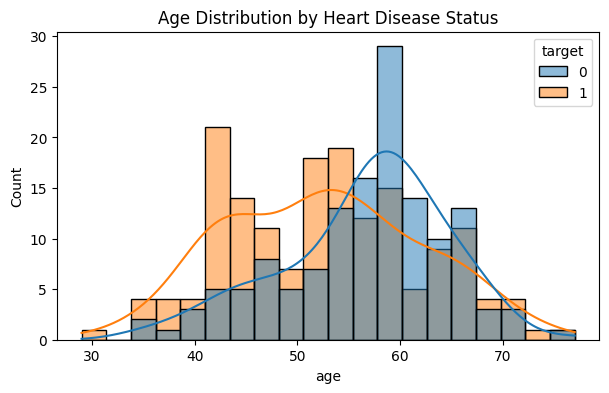

In [5]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="age", hue="target", kde=True, bins=20)
plt.title("Age Distribution by Heart Disease Status")
plt.show()

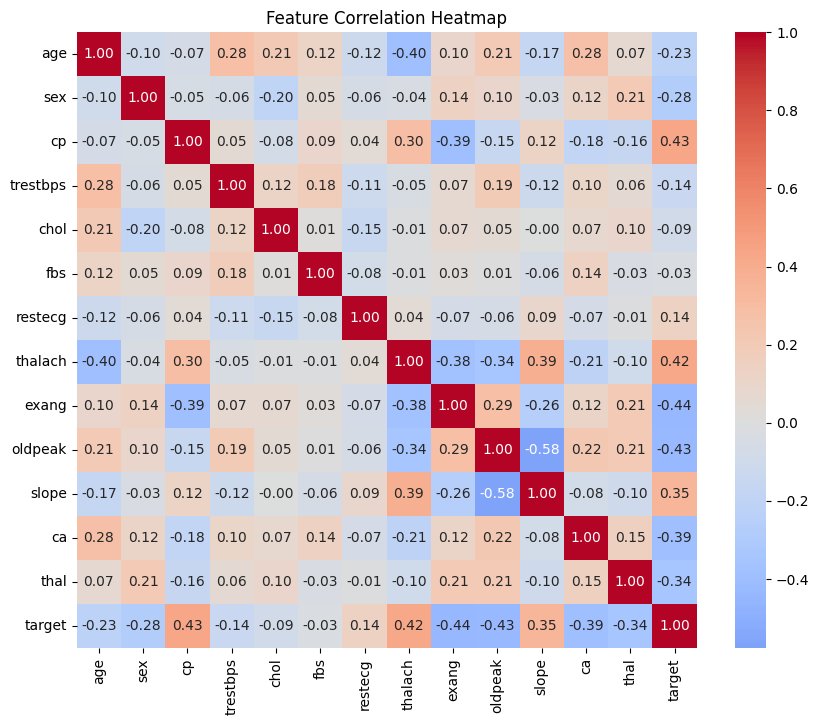

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

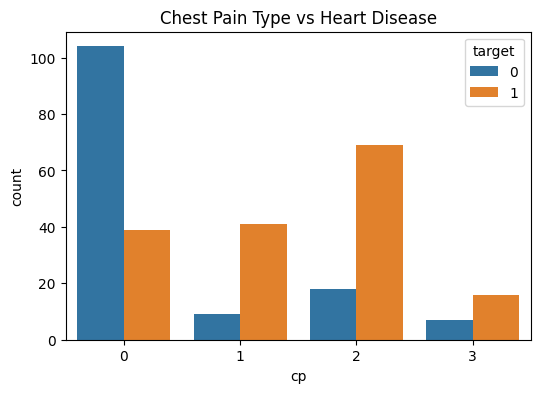

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x="cp", hue="target", data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

In [8]:
X = df.drop("target", axis=1)
y = df["target"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
}

In [12]:
results = []
trained_models = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
print("\n Model Comparison")
print(results_df.to_string(index=False))



 Model Comparison
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
      Random Forest  0.819672   0.761905 0.969697  0.853333 0.908009
Logistic Regression  0.803279   0.769231 0.909091  0.833333 0.869048
            XGBoost  0.803279   0.756098 0.939394  0.837838 0.856061



Best model:  Random Forest

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.64      0.77        28
           1       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61



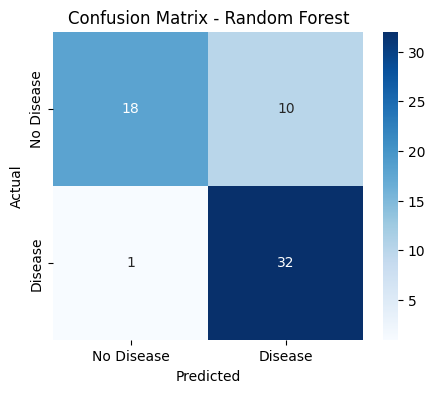

In [13]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print("\nBest model: ", best_model_name)

if best_model_name == "Logistic Regression":
    y_pred_best = best_model.predict(X_test_scaled)
    y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    y_pred_best = best_model.predict(X_test)
    y_proba_best = best_model.predict_proba(X_test)[:, 1]
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

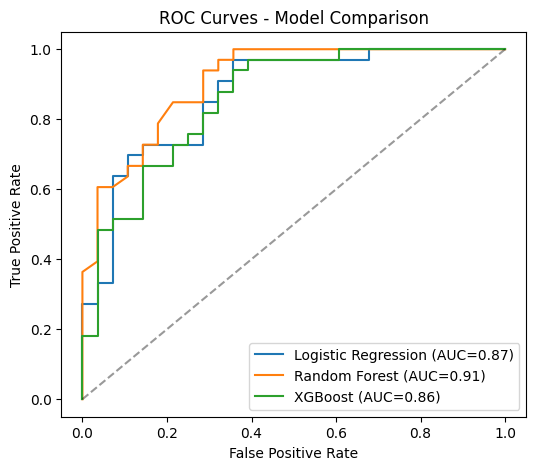

In [14]:
plt.figure(figsize=(6, 5))
for name, model in trained_models.items():
    if name == "Logistic Regression":
        proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
# Random guessing line
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend()
plt.show()

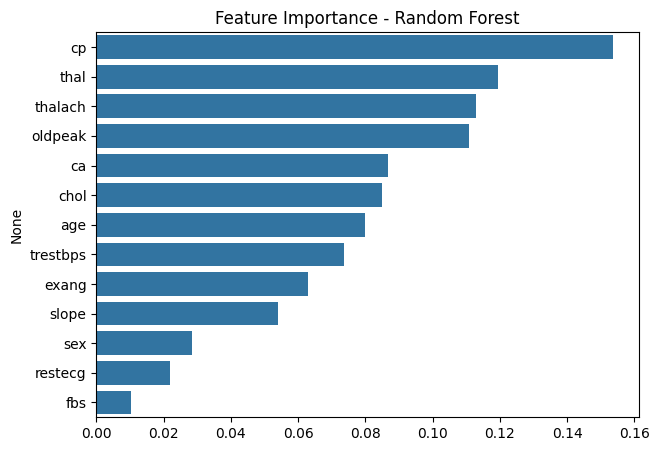

In [15]:
if best_model_name in ["Random Forest", "XGBoost"]:
    importances = pd.Series(best_model.feature_importances_,index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(7, 5))
    sns.barplot(
        x=importances.values,
        y=importances.index
    )
    plt.title(f"Feature Importance - {best_model_name}")
    plt.show()